<a href="https://colab.research.google.com/github/AquilaITOH/MedicalDataScience-exercises/blob/main/26Medical_datascience_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# メディカルデータサイエンス #5 パーセプトロンから深層学習へ

- パーセプトロン
  - 単純パーセプトロン: 線形分類器
  - 多層パーセプトロン: 非線形分類器

- パーセプトロンを使った分類器
  - 単純パーセプトロンでIrisを分類 (使用する特徴量は2次元)
    - データの分割、クロスバリデーション
    - 学習時の重み(w)とバイアス
    - 特徴空間の可視化、学習時の特徴空間
    - 機械学習における「学習」と「推論」
    - 勾配降下法
  - 多層パーセプトロンでIrisを分類 (使用する特徴量は2次元)
    - 非線形モデルの特徴空間の可視化
  - ハイパーパラメータの決定
  - 多層パーセプトロンでIrisを分類 (使用する特徴量は4次元)
  - ディープニューラルネットワーク(DNN: 深層学習)
    - 誤差伝播法
  - DNNでIrisを分類 (使用する特徴量は4次元)
  - DNNでIrisを分類 (使用する特徴量は2次元)

# ニューラルネットワーク

- 人間の脳の神経回路（ニューロン）を模倣した機械学習アルゴリズム
- データから特徴を自動学習してパターン認識を行う技術

- 現代のAIの基盤として画像認識、自然言語処理、音声認識などに広く応用される

## 各AIブームを牽引したAI技術

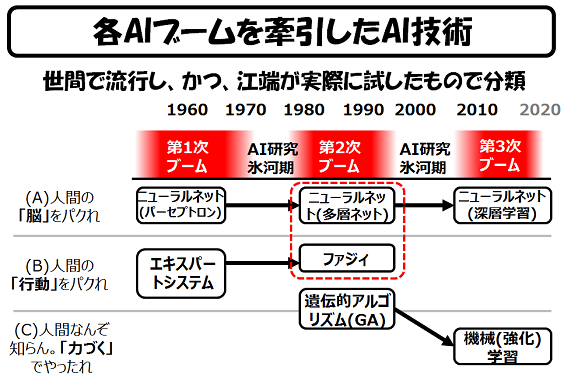

[江端智一. 不幸な人工知能 ～尊敬と軽蔑の狭間で揺れるニューラルネットワーク(2018)](https://eetimes.itmedia.co.jp/ee/articles/1804/27/news093.html)

## ニューロ・ファジィ家電の振り返り
[藤原義博, 若見昇, & 林勲. 松下電器から生まれたファジィ家電，ニューロ・ファジィ家電. 知能と情報 30, 14–23 (2018).](https://www.jstage.jst.go.jp/article/jsoft/30/1/30_14/_article/-char/ja/)

> 入力層のノードが3個、中間層が7個、出力層が1個の3層構造である(p.20)

#データ分析の準備
## ライブラリ・モジュールの読み込み

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as datasets
import sklearn.decomposition as decomposition
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron # Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss #lbfgsのloss記録
from matplotlib.colors import ListedColormap

## data setの読み込みとDFへのセット
Iris data setを読み込み、Pandas DataFrameにセットする

In [ ]:
#import sklearn.datasets as datasets
iris_data = datasets.load_iris()

iris_df = pd.DataFrame(iris_data.data, columns = iris_data.feature_names)
iris_df["species"] = iris_data.target_names[iris_data.target]

# パーセプトロン
生物の神経細胞を模したもの。ニューラルネットワークの素子で、単純パーセプトロンは線型分類器である。

## 神経細胞 (neuron)
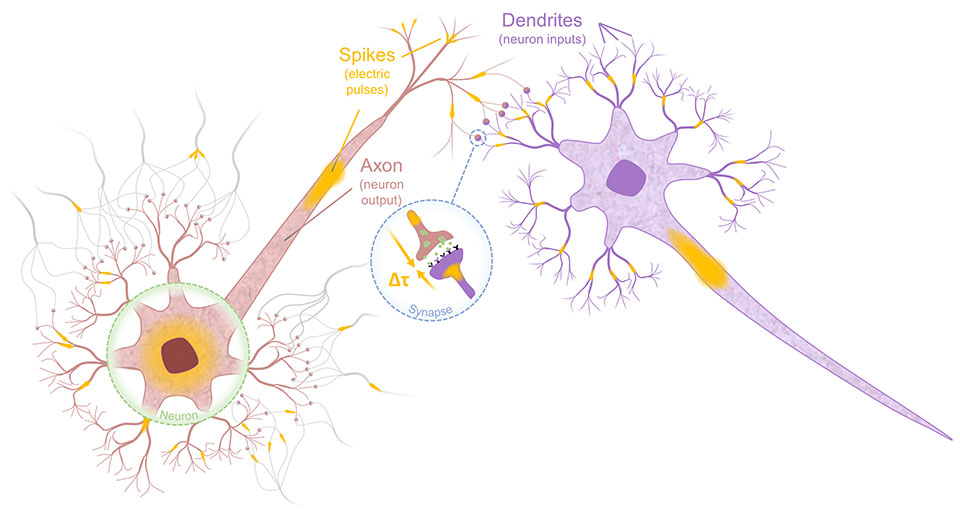
[Neuron and Synapse-Mimetic Spintronics Devices(2019-04-16)](https://www.tohoku.ac.jp/en/press/neuron_synapse_mimetic_spintronics_devices.html)

##パーセプトロン素子の動作

入力x1に重みw1をかける

入力x2に重みw2をかける

全部足して判定

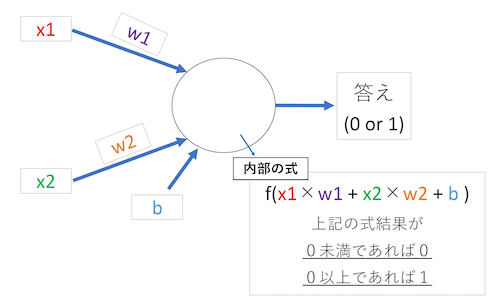

[機械学習・ディープラーニングについて「ど素人」が勉強してみました。 | 雑記ラボ](https://zakkilab.com/it/it-kikaigakusyu-sirouto/)


### 多クラス分類可能な単純パーセプトロン
[ 0, 1, 2] の三種類分類したい。(setosa, versicolor, virginica)

出力は3つ。どれかが1(0以上)になる。他は0

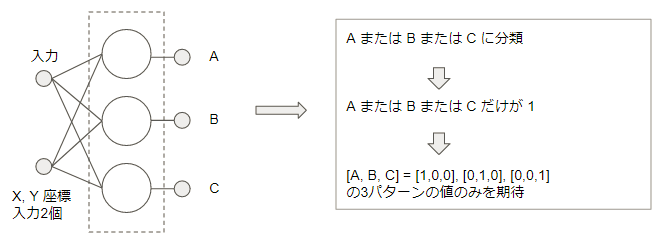

[入門 Keras (4) 多クラス分類 – Iris データを学習する｜技術ブログ｜北海道札幌市・宮城県仙台市のVR・ゲーム・システム開発 インフィニットループ](https://www.infiniteloop.co.jp/tech-blog/2018/01/learning-keras-04/)

#単純パーセプトロンでIrisを分類 (使用する特徴量は2次元)

scikt-learnのPerceptron を用いて多クラス分類をする。

[【初心者】ネコでも分かる「簡単な分類AI」の作り方【Python】](https://zenn.dev/nekoallergy/articles/sklearn-nn-iris)

## 分類に用いる特徴量の選択 (2次元のみ)
sepal length, sepal width, petal length, petal width

Pair plotを目視で確認し、三種類が分類できそうな特徴量を探す。

In [ ]:
# ペアプロットの作成
sns.pairplot(iris_df, hue='species', markers=["o", "s", "X"],corner=True, height=1.5) #hueで品種ごとの色分け、corner=Trueで重複するplotを省略
plt.show()

In [ ]:
# iris_dfの先頭3行を表示
iris_df.head(3)


分類に用いる特徴量の選択

[0, 1, 2, 3] = [sepal length, sepal width, petal length, petal width]

たとえば…

- **petal lengthとpetal width [2, 3] を特徴量として使う**
- sepal widthとpetal Length[1,2]を特徴量に使う

class lebels = [setosa, versicolor, virginica]

In [ ]:
feature_names = ['sepal length(cm)', 'sepal width(cm)', 'petal length(cm)', 'petal width(cm)']
selected_features = [2, 3]  # ここだけ変えれば全体に反映
X = iris_data.data[:, selected_features]
y = iris_data.target #正解ラベル

print('Class labels:', np.unique(y))

## 前処理

### データの分割

トレーニングデータとテストデータに分割する

- X_train: トレーニング用データ 70% (Setosa 35, Versicolor 35, Virginica 35)
- X_test: テスト用データ 30% (Setosa 15, Versicolor 15, Virginica 15)
- y_tarain: トレーニング用正解ラベル 70%
- y_test: テスト用正解ラベル 30%
- random seed = 1234 (乱数を固定する)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y)
print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

選択した特徴量の分布

In [ ]:
print(X_train)
print(y_train)
plt.scatter(X_train[:, 0], X_train[:, 1])
plt.xlabel(feature_names[selected_features[0]])
plt.ylabel(feature_names[selected_features[1]])
plt.tight_layout()
plt.show()

### スケーリング
StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。

In [ ]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

plt.figure(figsize=(5, 5))  # 正方形
plt.scatter(X_train_std[:,0],X_train_std[:,1])
plt.xlabel(feature_names[selected_features[0]])
plt.ylabel(feature_names[selected_features[1]])
plt.tight_layout()
plt.show()

スケーリング後のトレーニング用セットの特徴量

In [ ]:
print(X_train_std)

## 単純パーセプトロンモデルの作成(2次元入力)

分類のための予測モデル(単純パーセプトロン)を作成する

入力層(2次元) - 出力層 のみ

中間層(隠れ層)のないニューラルネットワーク

In [ ]:
#from sklearn.linear_model import Perceptron
#エポック数100、学習率0.1でパーセプトロンのインスタンスを作成(rand generatorのseed:random_state=1234)
ppn = Perceptron(max_iter=100, tol=1e-3, eta0=0.1, random_state=1234)


## 学習(トレーニング)

トレーニングデータを使って予測モデルを学習する

In [ ]:
#トレーニングデータをモデルに適合させる
ppn.fit(X_train_std, y_train)

## 推論、評価

テストデータによる精度評価。学習時には使用しなかったテストデータを用いて**推論**し、精度(的中率)を計算する。

学習時に使用しなないテストデータを用いて評価することを交差検定(cross varidation)という。

### 交差検定: cross varidation

In [ ]:
#テストデータの分類、結果の取得
y_pred = ppn.predict(X_test_std)
print("推論: %s" %ppn.predict(X_test_std))
print("教師: %s" %y_test)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

## 単純パーセプトロンモデルの詳細


入力層(二次元) - 出力層 のみ

中間層(隠れ層)のないニューラルネットワーク

### 重み(w)と切片(Bias)

ノード間の結びつきの強さ。「学習」で調整する

- x1, x2... : 特徴量
- w11, w12... : 重み
- x1w11 + x2w12 全部たす
- Bias: b1 それに一定の数たす

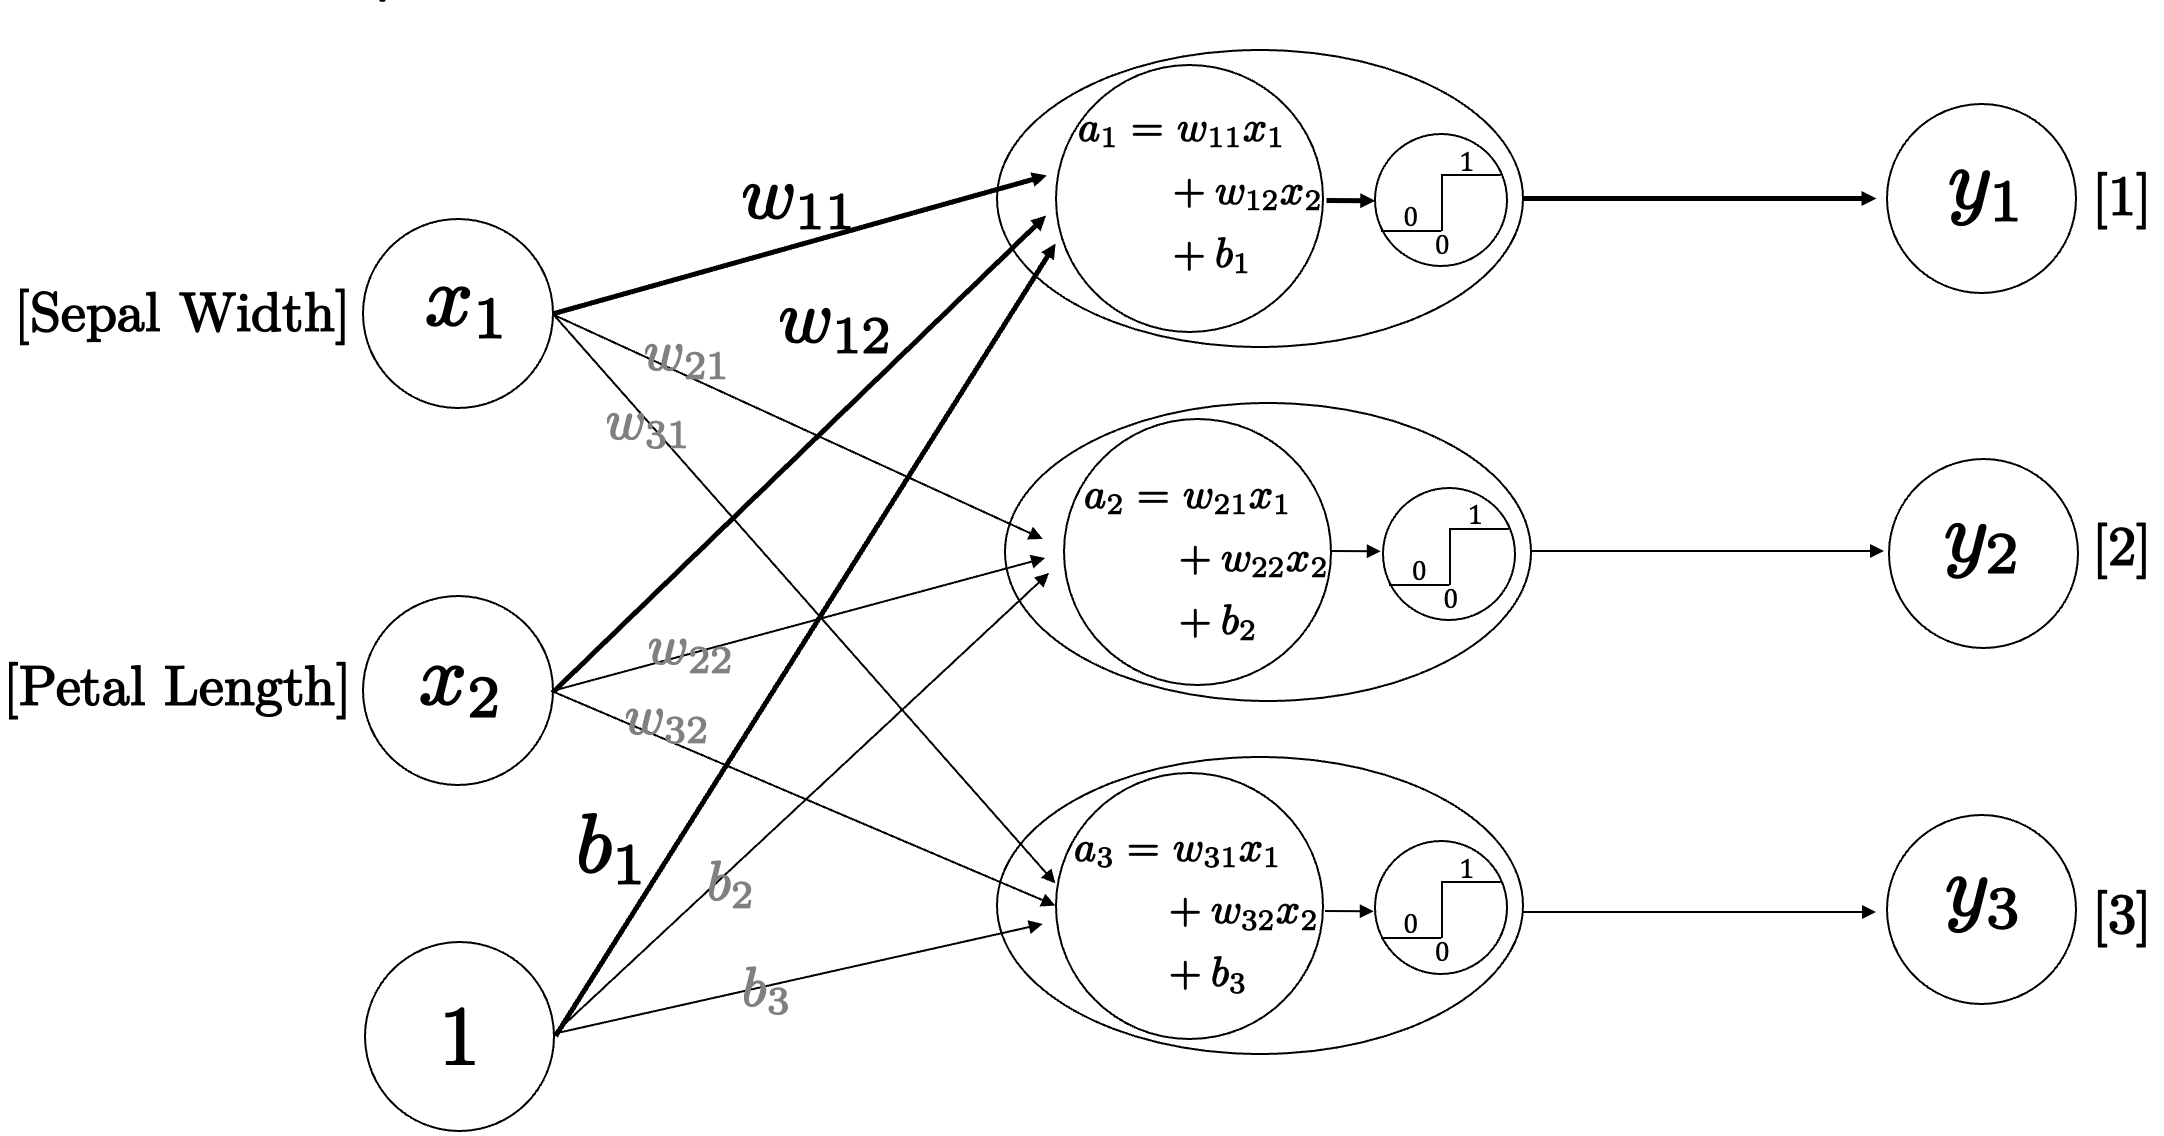


### 学習: トレーニングデータを用いて重み(w)とBiasを決定する

- クラスラベル: 結果の分類
- 重み: 3行2列の行列
- 切片: 1行3列の行列


In [ ]:
cls = ppn.classes_
coef= ppn.coef_
intrcpt = ppn.intercept_
print("分類クラスのユニークなクラスラベル =",ppn.classes_)
print("特徴量に割り当てられた重み",ppn.coef_)
print("切片",ppn.intercept_)

### 行列演算による表現

パーセプトロンの入出力は、行列演算で表現される。Scikit-learn等Pythonのライブラリ内部では行列演算が行われているが、通常は隠蔽されて目にすることはない。

ここでは、行列を使ってパーセプトロンの推論を計算してみる。

重み(w)とbiasを使ってパーセプトロンの出力(y1, y2, y3)を計算してみよう。

特徴量に重みをかけて総和をとり、切片をたす。行列を使うと式をコンパクトに表現できる。

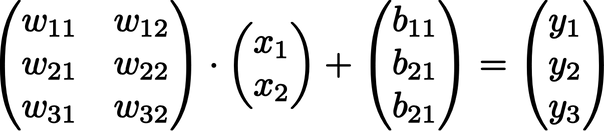

In [ ]:
n_raw = 0
a_in = X_test_std[n_raw,:]#特徴量
print("input: %s" %a_in)
print("y_test: %i" %(y_test[n_raw]))
print("y_pred: %i" %(y_pred[n_raw]))
#a_in = np.array([in1 , in2]) #入力
t_coef = np.transpose(coef) #特徴量
out = np.dot(a_in,t_coef) + intrcpt
print("output: %s" %out)
print("output(bool): %s" %(out>0)) #活性化関数はステップ関数
print("max value index: %s" %(np.argmax(out)))

#### 正解を確認する
test_dataの[n_raw]項目

In [ ]:
print(X_test_std[n_raw,:]) #特徴量
print(y_test[n_raw]) #正解ラベル

正解?

### テストデータセット全部を行列演算で推論してみる

テストデータは最初に分割した Setosa 15, Versicolor 15, Virginica 15

In [ ]:
i = 0 # インデックス値の初期値 0 を設定
len_in = len(X_test_std)
t_coef = np.transpose(coef) #転置

# インデックス値 < len_in の間、ループを繰り返す
while i < len_in:
  a_in = X_test_std[i,:]#特徴量
  print("input: %s" %a_in)
  print("y_test: %i" %(y_test[i]))
  print("y_pred: %i" %(y_pred[i]))
  out = np.dot(a_in,t_coef) + intrcpt
  print("output: %s" %out)
  print("output(bool): %s" %(out>0)) #活性化関数はステップ関数
  print("max value index: %s" %(np.argmax(out)))
  print("---")
  i+=1

## 特徴空間の可視化

予測モデルの特徴空間(線形関数)を散布図にプロットする。

In [ ]:
#from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

    # highlight test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
            X_test[:, 1],
            facecolor='none',
            edgecolor='black',
            alpha=1.0,
            linewidth=1,
            marker='o',
            s=100,
            label='test set')

Plot

In [ ]:
#Plot
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
plt.figure(figsize=(5, 5))  # 正方形
plot_decision_regions(X=X_combined_std, y=y_combined,
                      classifier=ppn, test_idx=range(105, 150))
plt.xlabel(feature_names[selected_features[0]] + ' [standardized]')
plt.ylabel(feature_names[selected_features[1]] + ' [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#トレーニング(学習）とは？

機械学習モデルのパラメーターを自動的に調整していくこと。
- 重み(w)
- bias

上の単純パーセプトロンが学習する際に特徴空間の分割が行われる様子。
30epocでは最適モデルへの収束に至っていない。
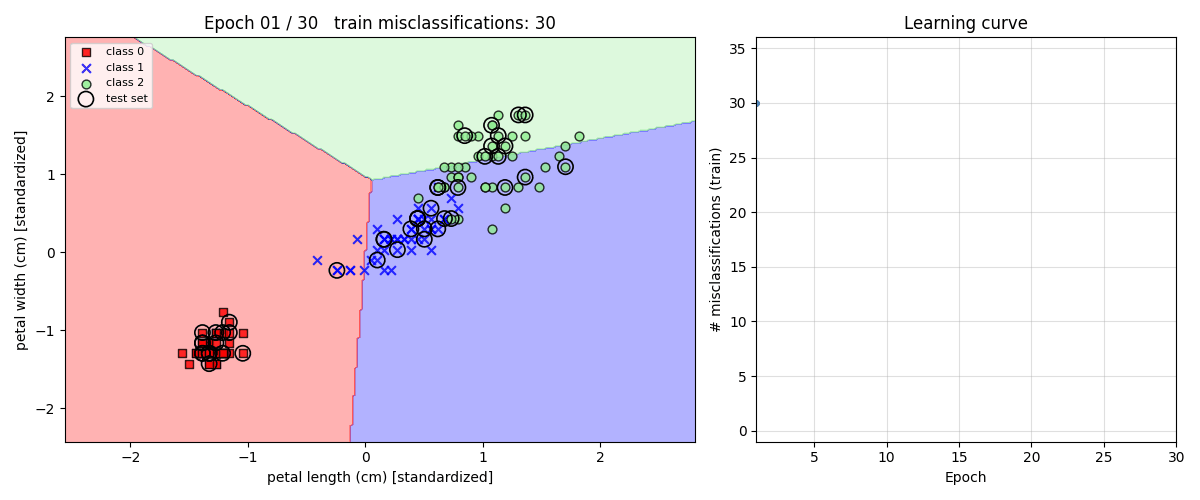

## 学習: 重み(w)やbiasの最適値を知りたい

モデルを算出するということは、[w]や[B]の要素を知ること。次元が少なければ解析解を得ることも可能。次元が多くなると困難になる。

そこでデータを用いて探索的に解を求める。これが**データ駆動**。

### 単層パーセプトロンのトレーニング

単層パーセプトロンは比較的簡単。

1. 重み(w) ((w11, w12),(w21,w22),(w31,w32)) にとりあえずランダムな値を設定する
2. トレーニングデータ(x1, x2)を一つ読み込み計算をして (y1, y2, y3)を正解と照合する。
3.  (y1, y2, y3)が正解と違っていれば、(w)の値を「正しそうな方向」に少しずらす
4. 2-3を繰り返し、全てのトレーニングデータについて正しい出力が得られたら終了

これを重みベクトルの自動更新と呼ぶ

「正しそうな方向」がwを増やす方向か、減らす方かは、**損失関数**の傾きで判断する。

### **勾配降下法**

「ある教師データを読み込ませたときの出力がどれくらい期待外れだったか？」を数値で返す関数 E があるとする。

これを誤差関数、あるいは**損失関数**と呼ぶ。

この関数は「出力が期待外れであるほど大きな値を返す」ものであれば何でも良い

誤差関数の出力値は「期待外れの度合い」なので、それを最小にできれば学習完了したと見なせる。

[w]をランダムな値で初期化してから少しずつ動かしていき、誤差関数の出力値を最小にする。

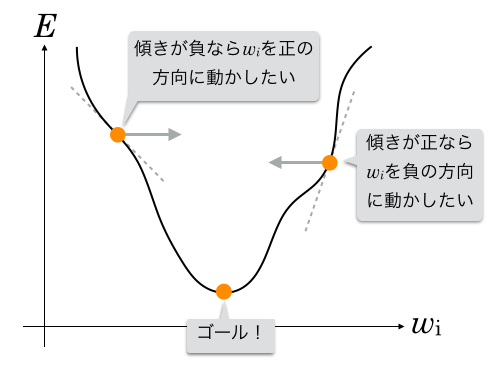

このグラフで「誤差Eが一番小さくなるw_i」は曲線が下方向に突起している箇所なので、目指したいのはここ。

- 現在のw_iでグラフの傾きが正の場合 → w_i を負の方向に動かす
- 現在のw_iでグラフの傾きが負の場合 → w_i を正の方向に動かす

[http://hokuts.com/2015/11/25/ml2_perceptron/](http://hokuts.com/2015/11/25/ml2_perceptron/)

#多層パーセプトロンでIrisを分類 (使用する特徴量は2次元)

多層パーセプトロン（MLP）は、入力層、隠れ層（中間層）、出力層の最低3層で構成される順伝播型ニューラルネットワークである。各ニューロンは全結合し、非線形な活性化関数を用いて、単純なパーセプトロンでは不可能な複雑な非線形分離問題を解くことができる。誤差逆伝播法を用いて学習を行う。




## 分類に用いる特徴量の選択
[0, 1, 2, 3] = [sepal length, sepal width, petal length, petal width]

In [ ]:
feature_names = ['sepal length(cm)', 'sepal width(cm)', 'petal length(cm)', 'petal width(cm)']
selected_features = [2, 3]  # ここだけ変えれば全体に反映
X = iris_data.data[:, selected_features]
y = iris_data.target #正解ラベル

## 前処理

データの分割、スケーリングを行う
単純パーセプトロンと同様。

In [ ]:
# データの分割
#トレーニングデータとテストデータに分割する。 単純パーセプトロンと同様。
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y)
# スケーリング
#StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## 多層パーセプトロンモデル

入力層(2次元) - **中間層(隠れ層)** - 出力層

単純パーセプトロンにはなかった中間層(隠れ層)がある。

2層目の隠れ層は5個ノードの3層型ニューラルネットワーク

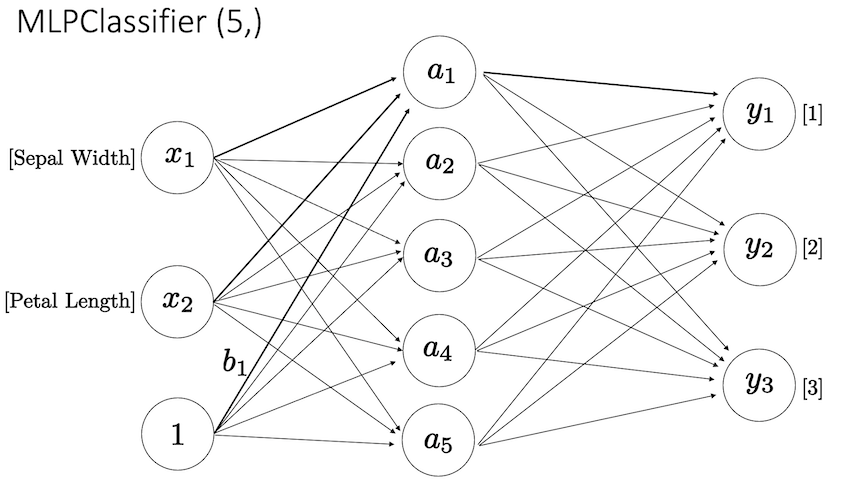

In [ ]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf5 = MLPClassifier(hidden_layer_sizes=(5,), activation='relu',
                    solver='adam', max_iter=1000)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (5,)2層目の隠れ層は5個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数

## 学習(トレーニング)

トレーニングデータによる予測モデル学習。単純パーセプトロンと同様。

In [ ]:
# Lerning model
clf5.fit(X_train_std, y_train)

## 推論、評価

### トレーニングデータによる精度評価

In [ ]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf5.score(X_train_std, y_train))

### 交差検定: cross validation

テストデータによる精度評価

In [ ]:
# Predict test data
print("予測: %s" %clf5.predict(X_test_std))
print("教師: %s" %y_test)

# score
y_pred = clf5.predict(X_test_std)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

## 学習過程の表示

学習を繰り返すほど**損失関数**の値が減少する。

(損失関数: 正解との差}

減少の程度を確認し、必要な学習回数(Iteration)を決める。

In [ ]:
# Show loss function (数列表示)
# print(clf5.loss_curve_)

# Show loss curve
plt.plot(clf5.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 特徴空間の可視化


In [ ]:
# PyLearnMLCR01: 決定木 | 知能情報システム工学研究室 – 日本大学生産工学部マネジメント工学科
# http://int-info.com/PyLearn/PyLearnMLCR01.html

Xmin, Ymin, Xmax, Ymax = -4, -4, 4, 4 # 空間の最小最大値
resolution = 0.1 # 細かさ
x_mesh, y_mesh = np.meshgrid(np.arange(Xmin, Xmax, resolution),
                             np.arange(Ymin, Ymax, resolution))
MeshDat = np.array([x_mesh.ravel(), y_mesh.ravel()]).T
#print(np.shape(MeshDat))
#print(MeshDat)

z = clf5.predict(MeshDat)
z = np.reshape(z,(len(x_mesh),len(y_mesh)))
#print(z)

# 推論(Setosa, Versicolor, Virginica領域)
plt.figure(figsize=(9,9))
plt.scatter(x_mesh[z==0], y_mesh[z==0], s=20, alpha=0.2, marker="s", c='red')
plt.scatter(x_mesh[z==1], y_mesh[z==1], s=20, alpha=0.2, marker="s", c='blue')
plt.scatter(x_mesh[z==2], y_mesh[z==2], s=20, alpha=0.2, marker="s", c='lightgreen')

#トレーニングデータ(Setosa, Versicolor, Virginica)
x0tr = X_train_std[y_train==0][:, 0] #ブール配列によるマスキング
y0tr = X_train_std[y_train==0][:, 1]
x1tr = X_train_std[y_train==1][:, 0]
y1tr = X_train_std[y_train==1][:, 1]
x2tr = X_train_std[y_train==2][:, 0]
y2tr = X_train_std[y_train==2][:, 1]
plt.scatter(x0tr, y0tr, alpha=0.8, marker="s", c='red', edgecolor='black',label="Setosa")
plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
plt.scatter(x2tr, y2tr, alpha=0.8, marker="o", c='lightgreen',edgecolor='black',label="Virginica")

#テストデータ(Setosa, Versicolor, Virginica)
x0ts = X_test_std[y_test==0][:, 0]
y0ts = X_test_std[y_test==0][:, 1]
x1ts = X_test_std[y_test==1][:, 0]
y1ts = X_test_std[y_test==1][:, 1]
x2ts = X_test_std[y_test==2][:, 0]
y2ts = X_test_std[y_test==2][:, 1]
plt.scatter(x0ts, y0ts, alpha=0.8, marker="s", c='red', edgecolor='black')
plt.scatter(x0ts, y0ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black',label='test set')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", c='lightgreen',edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')


plt.title("Feature space")
plt.xlabel(feature_names[selected_features[0]] + ' [standardized]')
plt.ylabel(feature_names[selected_features[1]] + ' [standardized]')

plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(loc='upper left')
#plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))

## 適切なハイパーパラメータの探索

モデルに手動で与えなければならないパラメータをハイパーパラメータと呼ぶ(ニューラルネットワークの隠れ層の数など)。これを片っ端から試して適当な組み合わせを探索する方法として、**グリッドサーチ**がある。
考えられる組み合わせを全て計算してみる方法である。

In [ ]:
# Grid Search with 交差検証（特徴量2つ）
results = []
for hidden_layer_sizes in [5, 10, 100, 1000]:
    for solver in ['sgd', 'adam', 'lbfgs']:
        for activation in ['identity', 'logistic', 'tanh', 'relu']:
            for learning_rate_init in [0.1, 0.01, 0.001]:
                clf = MLPClassifier(max_iter=10000,
                       hidden_layer_sizes=(hidden_layer_sizes,),
                       activation=activation, solver=solver,
                       learning_rate_init=learning_rate_init)
                scores = cross_val_score(clf, X_train_std, y_train, cv=5)
                results.append([hidden_layer_sizes, activation,
                       solver, learning_rate_init,
                       scores.mean(), scores.std()])

# 結果表示
df_results = pd.DataFrame(
    sorted(results, key=lambda f: f[4], reverse=True),
    columns=["hidden_layer_sizes", "activation", "solver",
             "learning_rate_init", "score_mean", "score_std"]
)
df_results

最良の結果となった組み合わせで新しくニューラルネットワーク(clf6)を作成する。



In [ ]:
# ニューラルネットワークのモデルを作成
clf6 = MLPClassifier(hidden_layer_sizes=(10,), activation='tanh',
                    solver='lbfgs', learning_rate_init = 0.001, max_iter=1000)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (5,)2層目の隠れ層は5個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数

# Lerning model
clf6.fit(X_train_std, y_train)

# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf6.score(X_train_std, y_train))

# Predict test data
print("予測: %s" %clf6.predict(X_test_std))
print("教師: %s" %y_test)

# score
y_pred = clf6.predict(X_test_std)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

# confidence level
conf_clf6 = pd.DataFrame(clf6.predict_proba(X_test_std))
conf_clf6.head(10)

# Show loss function
#print(clf6.loss_curve_)

### よりよいモデルの特徴空間の可視化

非線形分類されていることがわかる

In [ ]:
# PyLearnMLCR01: 決定木 | 知能情報システム工学研究室 – 日本大学生産工学部マネジメント工学科
# http://int-info.com/PyLearn/PyLearnMLCR01.html

Xmin, Ymin, Xmax, Ymax = -4, -4, 4, 4 # 空間の最小最大値
resolution = 0.1 # 細かさ
x_mesh, y_mesh = np.meshgrid(np.arange(Xmin, Xmax, resolution),
                             np.arange(Ymin, Ymax, resolution))
MeshDat = np.array([x_mesh.ravel(), y_mesh.ravel()]).T
#print(np.shape(MeshDat))
#print(MeshDat)

z6 = clf6.predict(MeshDat)
z6 = np.reshape(z6,(len(x_mesh),len(y_mesh)))
#print(z)
plt.figure(figsize=(9,9))
plt.scatter(x_mesh[z6==0], y_mesh[z6==0], s=20, alpha=0.2, marker="s", c='red')
plt.scatter(x_mesh[z6==1], y_mesh[z6==1], s=20, alpha=0.2, marker="s", c='blue')
plt.scatter(x_mesh[z6==2], y_mesh[z6==2], s=20, alpha=0.2, marker="s", c='lightgreen')

#トレーニングデータ(Setosa, Versicolor, Virginica)
x0tr = X_train_std[y_train==0][:, 0] #ブール配列によるマスキング
y0tr = X_train_std[y_train==0][:, 1]
x1tr = X_train_std[y_train==1][:, 0]
y1tr = X_train_std[y_train==1][:, 1]
x2tr = X_train_std[y_train==2][:, 0]
y2tr = X_train_std[y_train==2][:, 1]
plt.scatter(x0tr, y0tr, alpha=0.8, marker="s", c='red', edgecolor='black',label="Setosa")
plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
plt.scatter(x2tr, y2tr, alpha=0.8, marker="o", c='lightgreen',edgecolor='black',label="Virginica")

#テストデータ(Setosa, Versicolor, Virginica)
x0ts = X_test_std[y_test==0][:, 0]
y0ts = X_test_std[y_test==0][:, 1]
x1ts = X_test_std[y_test==1][:, 0]
y1ts = X_test_std[y_test==1][:, 1]
x2ts = X_test_std[y_test==2][:, 0]
y2ts = X_test_std[y_test==2][:, 1]
plt.scatter(x0ts, y0ts, alpha=0.8, marker="s", c='red', edgecolor='black')
plt.scatter(x0ts, y0ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black',label='test set')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", c='lightgreen',edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')


plt.title("Feature space")
plt.xlabel(feature_names[selected_features[0]] + ' [standardized]')
plt.ylabel(feature_names[selected_features[1]] + ' [standardized]')

plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(loc='upper left')
#plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))

### 学習過程のLossについて

In [ ]:
# solverがlbfgsで反復回数で収束しない
# Show loss curve
plt.plot(clf6.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

下のLossと反復回数による損失関数はあまり意味がありません…

In [ ]:
# lbfgs はバッチ最適化のため逐次的な損失を記録ない。lbfgs は小規模データに向いた準ニュートン法で、本来は反復回数ではなく収束条件で動作する#
#エポックごとに手動で損失を記録するが逐次的に収束を目指していないので、Iterartionの回数の関数で見ることに意味がない
losses = []
for _ in range(200):
    clf6.fit(X_train, y_train)
    prob = clf6.predict_proba(X_train)
    losses.append(log_loss(y_train, prob))

plt.plot(losses)
plt.title("Loss Curve (lbfgs, manual)")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

# 多層パーセプトロンでIrisを分類 (使用する特徴量は4次元)

分類に **4次元** すべての特徴量を使う

## 4次元の特徴量で分類する
下記4次元の特徴量で分類する。2次元より高い精度で分類できるはず。
- Sepal.Length (がく)
- Sepal.Width
- Petal.Length (花弁)
- Petal.Width

## 前処理
基本的にはこれまで同様。

In [ ]:
# 4 (all)dimention
# Split the dataset
data_train, data_test, target_train, target_test = train_test_split(
    iris_data.data, iris_data.target, test_size=0.3, random_state=0)
# スケーリング
#StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。
sc = StandardScaler()
sc.fit(data_train)
data_train_std = sc.transform(data_train)
data_test_std = sc.transform(data_test)

## 4次元入力の多層パーセプトロンモデル

入力層(**4次元**) - 中間層(隠れ層)10ノード - 出力層

4入力2層目の隠れ層は10個の、3層型ニューラルネットワーク
(下図は隠れ層5個で描画)
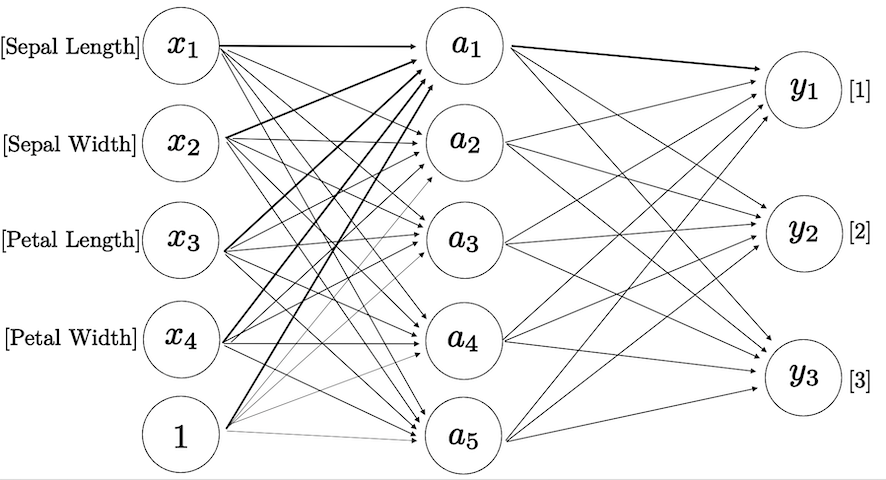



In [ ]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf4 = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                    solver='adam', max_iter=500)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (10,)2層目の隠れ層は10個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数


## 学習(トレーニング)

トレーニングデータによる予測モデル学習。これまでと同様。


In [ ]:
# Lerning model
clf4.fit(data_train_std, target_train)

## 評価
これまでと同様。

In [ ]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf4.score(data_train_std, target_train))

# Cross VaridationPredict test data
print("予測: %s" %clf4.predict(data_test_std))
print("教師: %s" %target_test)

target_pred = clf4.predict(data_test_std)
print('誤分類: %d' % (target_test != target_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(target_test, target_pred))

## 学習過程の表示

損失関数の減少過程を確認する。多層パーセプトロンモデルと同様

In [ ]:
# Show loss curve
plt.plot(clf4.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 特徴空間の可視化は可能か？

特徴量を4つ使って分類しているため、特徴空間は4次元になる。視覚化は困難。

正答率は高い?

# ディープニューラルネットワーク (DNN)

隠れ層を増やす
- a(1)
- a(2)

隠れ層が3層以上あるもの→ **ディープニューラルネットワーク**

**深層学習**


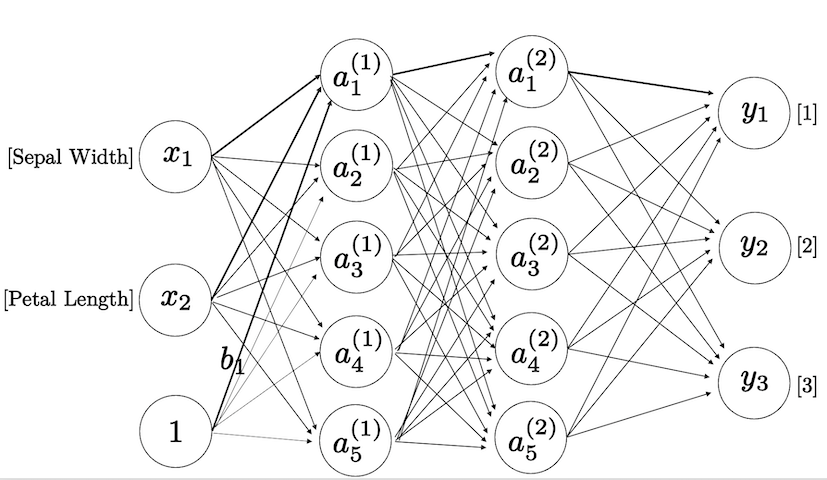

## DNNの学習における困難

乱数シードと勾配降下法だけでは深層NNの学習は不可能。

一層目の重みを調整しても、二層目以降の重みで損失はいかようにも変わる。


### 誤差逆伝播法(back propergation)

教師データを入力し、出力の正解との照らし合わせで答え合わせをしながら、重み付けの調整を推論と逆方向に行い、精度を上げていく学習方法。

誤差逆伝播法が確立して、多層NNの学習が可能になった。

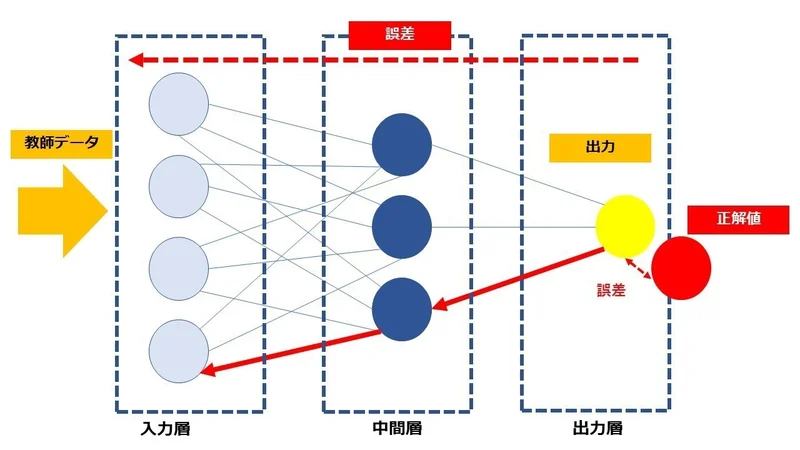

[【3分で理解】ニューラルネットワークを解説！後編「多層パーセプトロン」とは？｜村田泰祐](https://note.com/taisuke_murata/n/nb470ea2eaa8e)

## 前処理
これまでと同様

In [ ]:
# 4 (all)dimention
# Split the dataset
data_train, data_test, target_train, target_test = train_test_split(
    iris_data.data, iris_data.target, test_size=0.3, random_state=0)
# スケーリング
#StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。
sc = StandardScaler()
sc.fit(data_train)
data_train_std = sc.transform(data_train)
data_test_std = sc.transform(data_test)

## DNNでIrisを分類 (使用する特徴量は4次元)

In [ ]:
# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf4deep = MLPClassifier(hidden_layer_sizes=(10,10,10), activation='relu',
                    solver='adam', max_iter=500)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (10,)2層目の隠れ層は10個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数


### 学習(トレーニング)
スクリプトはこれまでと同様。
back propergationはライブラリで実施。

In [ ]:
# Lerning model
clf4deep.fit(data_train_std, target_train)

### 評価
これまでと同様。

In [ ]:
# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf4deep.score(data_train_std, target_train))

# Cross VaridationPredict test data
print("予測: %s" %clf4deep.predict(data_test_std))
print("教師: %s" %target_test)

target_pred = clf4deep.predict(data_test_std)
print('誤分類: %d' % (target_test != target_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(target_test, target_pred))


**テスト正答率が高い(はず…)！**

## 学習過程の表示
損失関数の減少過程を確認する。これまでと同様

In [ ]:
# Show loss function (数列表示)
#print(clf4deep.loss_curve_)

# Show loss curve
plt.plot(clf4deep.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 特徴空間の可視化は？

特徴空間が4次元なので可視化できない。

特徴空間が2次元であれば可視化できる。
-> 入力層を2次元にすればよい

# DNNでIrisを分類 (使用する特徴量は2次元)

In [ ]:
# 分類に使う特徴量の選択
feature_names = ['sepal length(cm)', 'sepal width(cm)', 'petal length(cm)', 'petal width(cm)']
selected_features = [2, 3]  # ここだけ変えれば全体に反映
X = iris_data.data[:, selected_features]
y = iris_data.target #正解ラベル

# 前処理
# データの分割
#トレーニングデータとテストデータに分割する。 単純パーセプトロンと同様。
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y)
# スケーリング
#StandardScalerを使って、平均0, 分散1となるようにデータをスケーリングする。
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# 2次元 3層DNNを構築する。

# Scikit Learnのニューラルネットワークのライブラリを読み込む
# from sklearn.neural_network import MLPClassifier
# ニューラルネットワークのモデルを作成
clf2deep = MLPClassifier(hidden_layer_sizes=(10,10,10), activation='relu',
                    solver='adam', max_iter=5000)
#hidden_layer_sizes 中間層(隠れ層)のサイズ (10,)2層目の隠れ層は10個の、3層型NN
#activation 活性化関数
#solver 最適化手法
#max_iter 繰り返し回数

# Lerning model
clf2deep.fit(X_train_std, y_train)

# Calculate prediction accuracy
print("トレーニング正答率: %.2f" %clf2deep.score(X_train_std, y_train))

# Cross Varidation Predict test data
print("予測: %s" %clf2deep.predict(X_test_std))
print("教師: %s" %y_test)

y_pred = clf2deep.predict(X_test_std)
print('誤分類: %d' % (y_test != y_pred).sum())
print('テスト正答率: %.2f' % accuracy_score(y_test, y_pred))

print("予測: %s" %clf2deep.predict(X_test_std))
print("教師: %s" %y_test)

# Show loss curve
plt.plot(clf2deep.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

# PyLearnMLCR01: 決定木 | 知能情報システム工学研究室 – 日本大学生産工学部マネジメント工学科
# http://int-info.com/PyLearn/PyLearnMLCR01.html

Xmin, Ymin, Xmax, Ymax = -4, -4, 4, 4 # 空間の最小最大値
resolution = 0.1 # 細かさ
x_mesh, y_mesh = np.meshgrid(np.arange(Xmin, Xmax, resolution),
                             np.arange(Ymin, Ymax, resolution))
MeshDat = np.array([x_mesh.ravel(), y_mesh.ravel()]).T
#print(np.shape(MeshDat))
#print(MeshDat)

z = clf2deep.predict(MeshDat)
z = np.reshape(z,(len(x_mesh),len(y_mesh)))
#print(z)

# 推論(Setosa, Versicolor, Virginica領域)
plt.figure(figsize=(9,9))
plt.scatter(x_mesh[z==0], y_mesh[z==0], s=20, alpha=0.2, marker="s", c='red')
plt.scatter(x_mesh[z==1], y_mesh[z==1], s=20, alpha=0.2, marker="s", c='blue')
plt.scatter(x_mesh[z==2], y_mesh[z==2], s=20, alpha=0.2, marker="s", c='lightgreen')

#トレーニングデータ(Setosa, Versicolor, Virginica)
x0tr = X_train_std[y_train==0][:, 0] #ブール配列によるマスキング
y0tr = X_train_std[y_train==0][:, 1]
x1tr = X_train_std[y_train==1][:, 0]
y1tr = X_train_std[y_train==1][:, 1]
x2tr = X_train_std[y_train==2][:, 0]
y2tr = X_train_std[y_train==2][:, 1]
plt.scatter(x0tr, y0tr, alpha=0.8, marker="s", c='red', edgecolor='black',label="Setosa")
plt.scatter(x1tr, y1tr, alpha=0.8, marker="x", c='blue',edgecolor='black',label="Versicolor")
plt.scatter(x2tr, y2tr, alpha=0.8, marker="o", c='lightgreen',edgecolor='black',label="Virginica")

#テストデータ(Setosa, Versicolor, Virginica)
x0ts = X_test_std[y_test==0][:, 0]
y0ts = X_test_std[y_test==0][:, 1]
x1ts = X_test_std[y_test==1][:, 0]
y1ts = X_test_std[y_test==1][:, 1]
x2ts = X_test_std[y_test==2][:, 0]
y2ts = X_test_std[y_test==2][:, 1]
plt.scatter(x0ts, y0ts, alpha=0.8, marker="s", c='red', edgecolor='black')
plt.scatter(x0ts, y0ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black',label='test set')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="x", c='blue',edgecolor='black')
plt.scatter(x1ts, y1ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", c='lightgreen',edgecolor='black')
plt.scatter(x2ts, y2ts, alpha=0.8, marker="o", s=100, facecolor='none', edgecolor='black')


plt.title("Feature space")
plt.xlabel(feature_names[selected_features[0]] + ' [standardized]')
plt.ylabel(feature_names[selected_features[1]] + ' [standardized]')

plt.grid(True)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend(loc='upper left')
#plt.legend(["Setosa", "Versicolor", "Virginica"], loc="upper right", bbox_to_anchor=(1.3, 1))